# 03. EDA: лоты (projects)

Данные: `eda_left.parquet` (выход 02c — отобранные колонки, типы, таргеты, дедуп).

1. Признаки модели — базовые распределения
2. Анализ таргета — какой использовать
3. Динамика: предложение, сделки, ключевая ставка
4. Полнота истории лота — видна ли с начала
5. Обрывы лотов без сделки
6. Задержка: последний прайс → регистрация сделки
7. Статус лота → колонка `unit_status`


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "data").is_dir() else _cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from src.config import EDA_LEFT_PARQUET, MACRO_XLSX

C1, C2, C3 = "#2C7BB6", "#D7542B", "#2D9E5F"
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.right": False, "axes.spines.top": False})
FIG_DIR = REPO_ROOT / "reports" / "figures" / "03_eda_projects"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(EDA_LEFT_PARQUET)
# порядковый номер среза внутри лота (ROW_NUMBER OVER PARTITION BY unit_match_key ORDER BY file_date)
df["row_number"] = df.sort_values(["unit_match_key", "file_date"]).groupby("unit_match_key").cumcount() + 1
print(f"{len(df):,} строк × {df.shape[1]} колонок  |  "
      f"{df['unit_match_key'].nunique():,} лотов  |  "
      f"{df['file_date'].min():%Y-%m} … {df['file_date'].max():%Y-%m}")


4,631,451 строк × 40 колонок  |  882,647 лотов  |  2021-02 … 2025-05


In [2]:
pd.set_option("display.max_columns", 60)

## 1. Признаки модели — базовые распределения

In [3]:
# Признаки, которые пойдут в модель прогнозирования продажи
NUM_FEATURES = {
    "price":        "Цена за м², ₽",
    "area":         "Площадь, м²",
    "floor":        "Этаж",
    "discount_pct": "Скидка, %",
    "exposure":     "Экспозиция, дней",
}
CAT_FEATURES = {
    "project_class":   "Класс проекта",
    "project_name":    "Название проекта",
    "region":          "Регион",
    "room_count":      "Комнатность",
    "premises_type":   "Тип помещения",
    "stage_k":         "Стадия строительства",
    "contract_type_k": "Тип договора",
    "finish_tier":     "Отделка",
}

# Сводка по числовым
display(df[list(NUM_FEATURES)].describe(percentiles=[.05, .5, .95]).T[["count", "mean", "5%", "50%", "95%", "max"]].round(1))


,count,mean,5%,50%,95%,max
price,4631451.0,285942.114613,128666.0,254370.0,543310.0,2727180.0
area,4631451.0,50.103281,22.7,44.8,89.1,491.7
floor,4631451.0,11.788937,2.0,10.0,28.0,67.0
discount_pct,4631450.0,2.720942,0.0,0.0,20.0,60.0
exposure,4117591.0,176.721388,0.0,103.0,592.0,8271.0


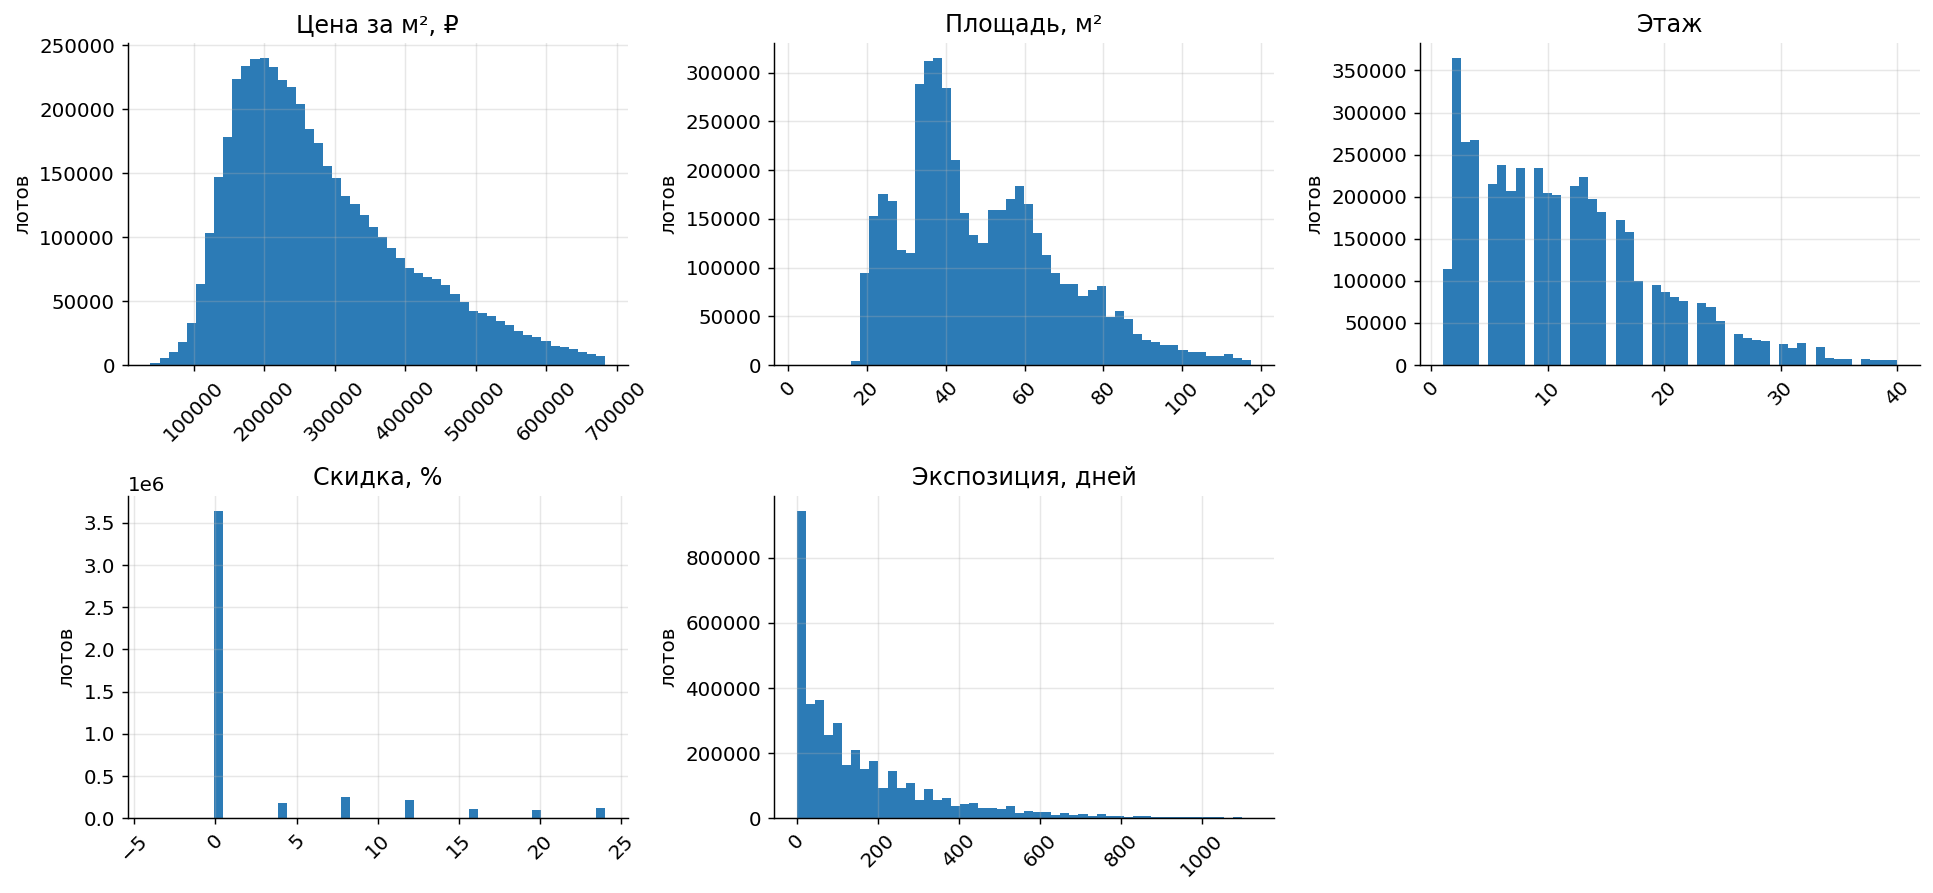

In [4]:
# Числовые — гистограммы (хвост обрезан по p99 для читаемости)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (col, label) in zip(axes.ravel(), NUM_FEATURES.items()):
    s = df[col].dropna()
    s = s[s <= s.quantile(0.99)]
    ax.hist(s, bins=50, color=C1, edgecolor="none")
    ax.set_title(label)
    ax.set_ylabel("лотов")
    ax.tick_params(axis="x", rotation=45)
for ax in axes.ravel()[len(NUM_FEATURES):]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_num_features.png", bbox_inches="tight")
plt.show()


In [5]:
df[df.unit_match_key == "1009@10858@1@104@9@89@3"]

,unit_match_key,project_id,building_id,project_name,developer,project_class,region,macro_district,district,sales_start,completion_k,premises_type,section,floor,finish_in_report,unit_typology,room_count,area,price,price_no_discount,discount_pct,finish_tier,finish_text,contract_type_k,stage_k,exposure,file_date,lat,lng,price_deals,price_deals_no_discount,registration_date_raw,pledge_type,mortgage,is_sold_past,is_sold,is_sold_next_month,is_sold_next_quarter,row_number,unit_status
97,1009@10858@1@104@9@89@3,1009,10858,Бутово Парк 2,ПИК,комфорт,Московская область,Ленинский городской округ,Дрожжино (п.г.т.),2020-12-01,2022-12-01,Квартира,1,9,<NA>,Евро,3,89.0,124162.0,124162.0,0.0,1 - Есть,прочее,Эскроу,котлован,0,2021-09-02,55.52291,37.59025,148660.0,148660.0,2022-06-07,ипотека,1.0,0,0,0,0,1,продан
98,1009@10858@1@104@9@89@3,1009,10858,Бутово Парк 2,ПИК,комфорт,Московская область,Ленинский городской округ,Дрожжино (п.г.т.),2020-12-01,2022-12-01,Квартира,1,9,<NA>,Евро,3,89.0,127186.0,127186.0,0.0,1 - Есть,прочее,Эскроу,котлован,31,2021-10-04,55.52291,37.59025,148660.0,148660.0,2022-06-07,ипотека,1.0,0,0,0,0,2,продан
99,1009@10858@1@104@9@89@3,1009,10858,Бутово Парк 2,ПИК,комфорт,Московская область,Ленинский городской округ,Дрожжино (п.г.т.),2020-12-01,2022-12-01,Квартира,1,9,<NA>,Евро,3,89.0,125412.0,125412.0,0.0,1 - Есть,прочее,Эскроу,нижние этажи,61,2021-11-02,55.52291,37.59025,148660.0,148660.0,2022-06-07,ипотека,1.0,0,0,0,0,3,продан
100,1009@10858@1@104@9@89@3,1009,10858,Бутово Парк 2,ПИК,комфорт,Московская область,Ленинский городской округ,Дрожжино (п.г.т.),2020-12-01,2022-12-01,Квартира,1,9,<NA>,Евро,3,89.0,123120.0,123120.0,0.0,1 - Есть,прочее,Эскроу,нижние этажи,91,2021-12-02,55.52291,37.59025,148660.0,148660.0,2022-06-07,ипотека,1.0,0,0,0,0,4,продан
101,1009@10858@1@104@9@89@3,1009,10858,Бутово Парк 2,ПИК,комфорт,Московская область,Ленинский городской округ,Дрожжино (п.г.т.),2020-12-01,2022-12-01,Квартира,1,9,<NA>,Евро,3,89.0,143760.0,143760.0,0.0,1 - Есть,прочее,Эскроу,нижние этажи,181,2022-03-02,55.52291,37.59025,148660.0,148660.0,2022-06-07,ипотека,1.0,0,0,0,0,5,продан
102,1009@10858@1@104@9@89@3,1009,10858,Бутово Парк 2,ПИК,комфорт,Московская область,Ленинский городской округ,Дрожжино (п.г.т.),2020-12-01,2022-12-01,Квартира,1,9,<NA>,Евро,3,89.0,148660.0,148660.0,0.0,1 - Есть,<NA>,Эскроу,нижние этажи,213,2022-04-04,55.52291,37.59025,148660.0,148660.0,2022-06-07,ипотека,1.0,0,1,0,1,6,продан


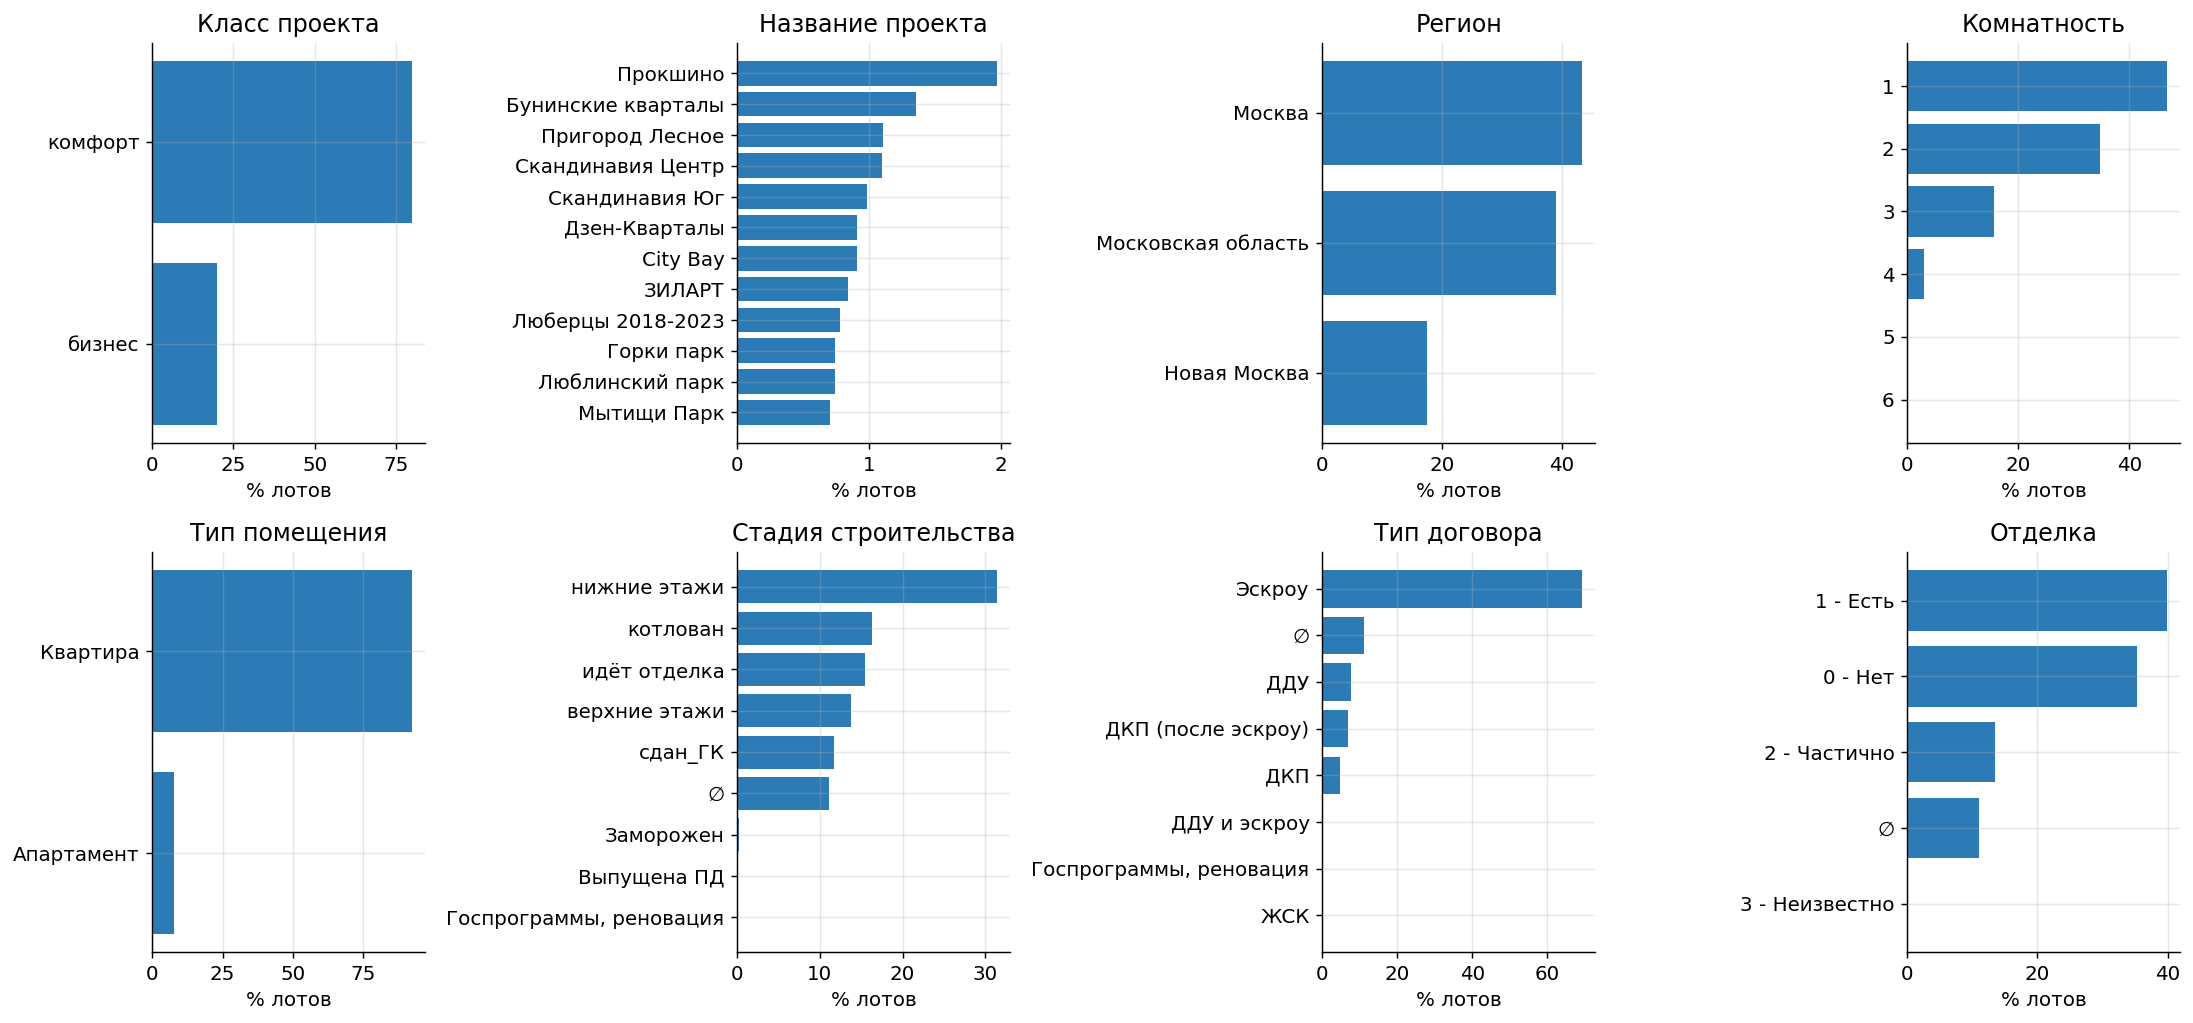

In [6]:
# Категориальные — доля лотов по значениям (топ-12)
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, (col, label) in zip(axes.ravel(), CAT_FEATURES.items()):
    share = 100 * df[col].astype("string").value_counts(dropna=False).head(12) / len(df)
    labels = ["∅" if pd.isna(i) else str(i) for i in share.index]
    ax.barh(labels[::-1], share.values[::-1], color=C1)
    ax.set_title(label)
    ax.set_xlabel("% лотов")
for ax in axes.ravel()[len(CAT_FEATURES):]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_cat_features.png", bbox_inches="tight")
plt.show()


## 2. Анализ таргета — какой использовать

Три варианта (метка ставится на ПОСЛЕДНЮЮ строку лота):
`is_sold` (продан когда-либо после среза), `is_sold_next_month` (≤30 дн.), `is_sold_next_quarter` (≤90 дн.).
Смотрим: насколько таргет редкий и какую долю реальных сделок он захватывает.

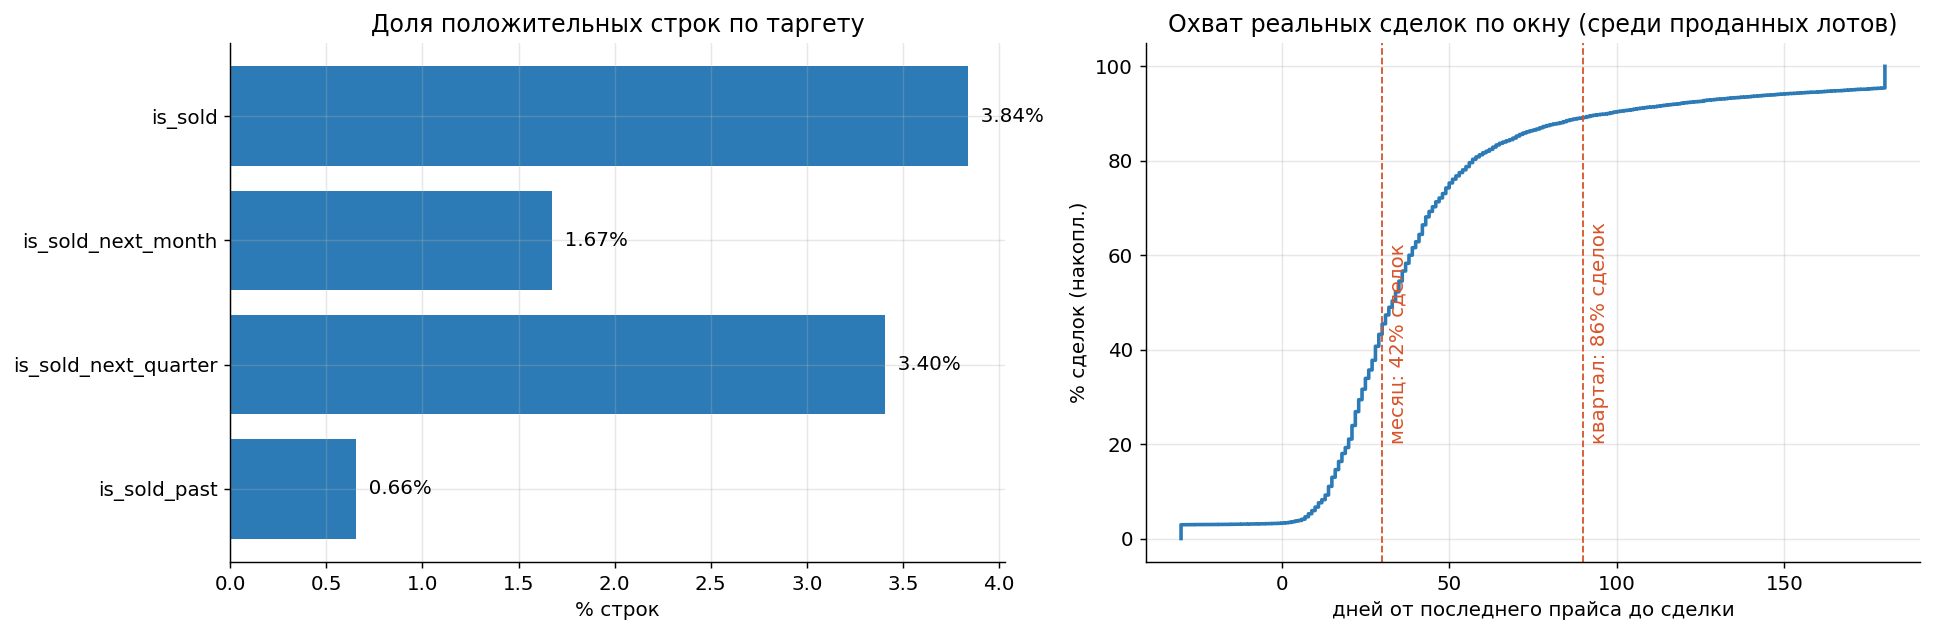

Проданных лотов: 183,578  |  медиана задержки: 33 дн.


In [7]:
TARGETS = ["is_sold", "is_sold_next_month", "is_sold_next_quarter", "is_sold_past"]

# задержка последнего прайса -> регистрация (на проданных лотах)
last_fd = df.groupby("unit_match_key")["file_date"].max()
sold = df.loc[df["registration_date_raw"].notna()].drop_duplicates("unit_match_key").copy()
sold["delta"] = (sold["registration_date_raw"] - sold["unit_match_key"].map(last_fd)).dt.days

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5))

# слева: доля положительных строк по таргетам
rates = [100 * df[t].mean() for t in TARGETS]
axL.barh(TARGETS[::-1], rates[::-1], color=C1)
for y, r in enumerate(rates[::-1]):
    axL.text(r, y, f"  {r:.2f}%", va="center")
axL.set_title("Доля положительных строк по таргету")
axL.set_xlabel("% строк")

# справа: какую долю сделок захватывает окно N дней (CDF задержки)
d = sold["delta"].clip(-30, 180)
order = np.sort(d.values)
cdf = np.arange(1, len(order) + 1) / len(order)
axR.plot(order, 100 * cdf, color=C1, lw=2)
for x, lbl in [(30, "месяц"), (90, "квартал")]:
    cov = 100 * ((sold["delta"] >= 0) & (sold["delta"] <= x)).mean()
    axR.axvline(x, color=C2, ls="--", lw=1)
    axR.text(x + 2, 20, f"{lbl}: {cov:.0f}% сделок", color=C2, rotation=90, va="bottom")
axR.set_title("Охват реальных сделок по окну (среди проданных лотов)")
axR.set_xlabel("дней от последнего прайса до сделки")
axR.set_ylabel("% сделок (накопл.)")

fig.tight_layout()
fig.savefig(FIG_DIR / "03_target.png", bbox_inches="tight")
plt.show()

print(f"Проданных лотов: {len(sold):,}  |  медиана задержки: {int(sold['delta'].median())} дн.")


**Вывод по таргету.** `is_sold_next_month` (≤30 дн.) захватывает ~42% сделок и редкий (1.7% строк); `is_sold_next_quarter` (≤90 дн.) ловит ~86% сделок при редкости 3.4%; `is_sold` (любой горизонт) — самый полный, но окно не ограничено по времени.
→ Базовый таргет: **`is_sold_next_month`** (30 дн.) — на коротком горизонте цена среза ближе к фактической цене сделки, что важнее для оценки ценовой чувствительности спроса; `is_sold_next_quarter` оставлен как альтернативный квартальный горизонт. Оба столбца сохраняются в `model_dataset`.

## 3. Динамика: предложение, сделки, ключевая ставка

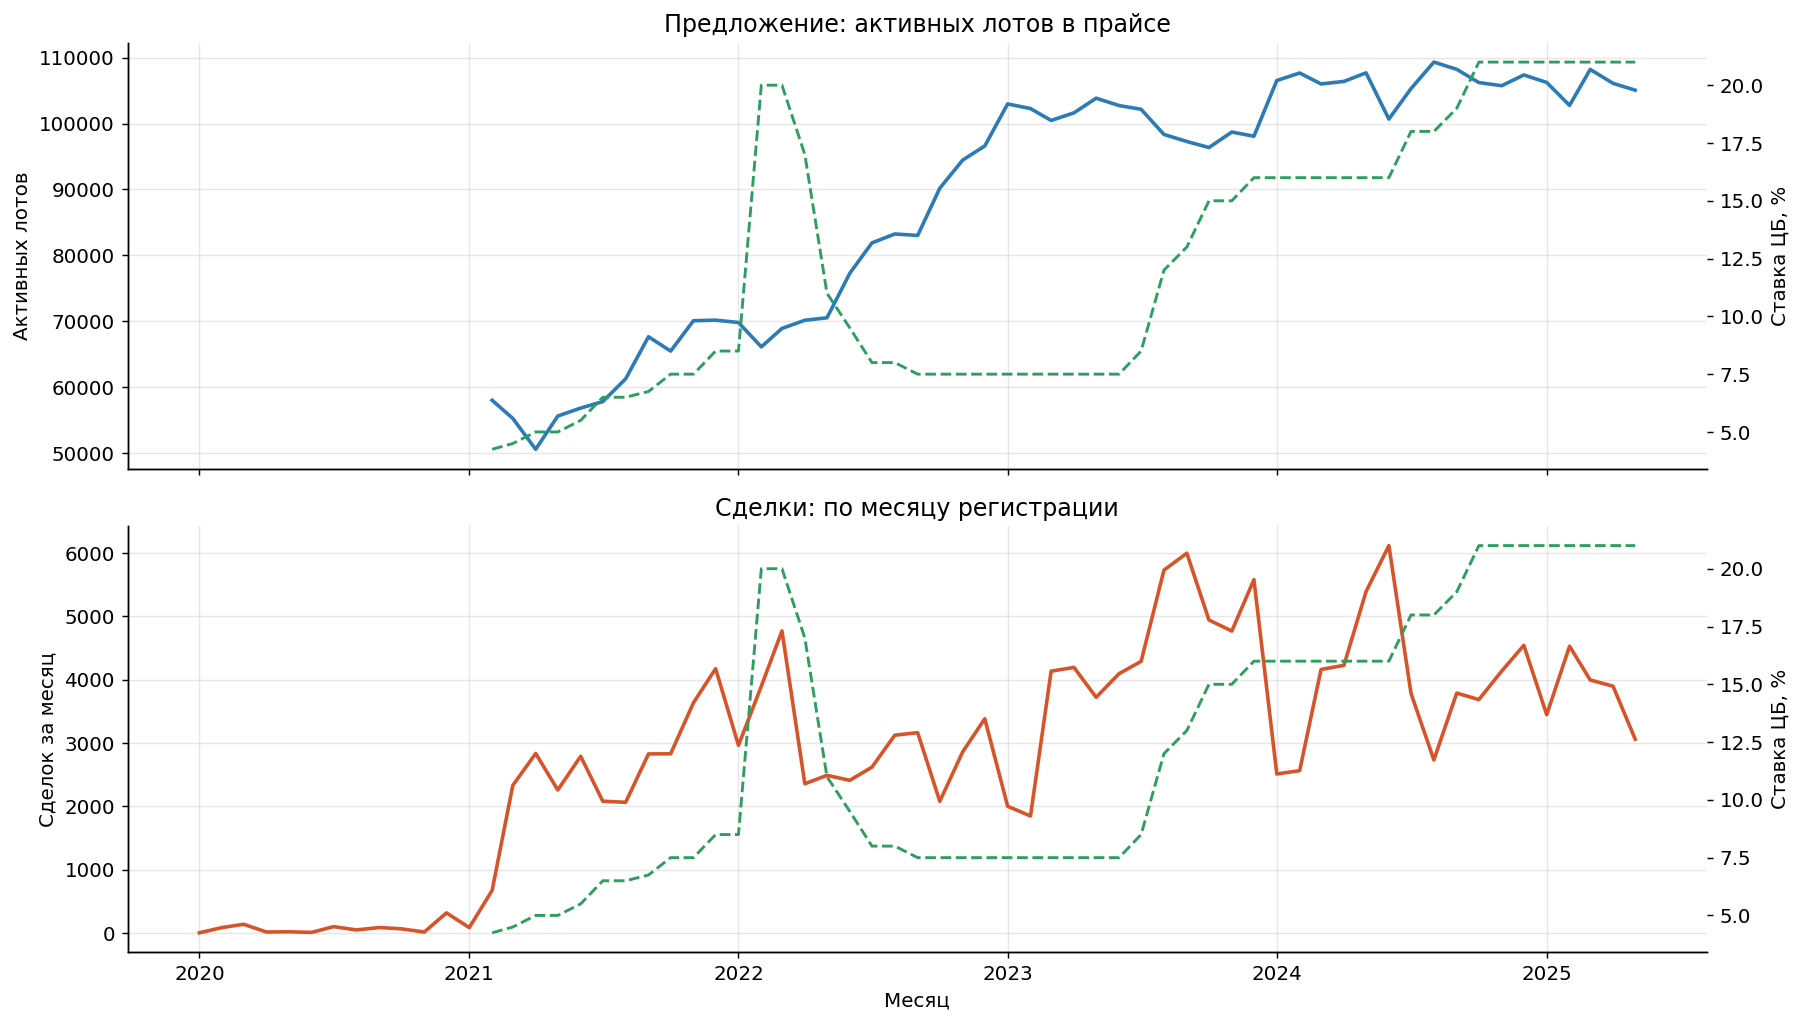

In [8]:
# предложение: активных лотов по месяцу прайса
supply = (df.assign(m=df["file_date"].dt.to_period("M").dt.start_time)
            .groupby("m")["unit_match_key"].nunique())

# сделки: уникальные проданные лоты по месяцу регистрации
sd = df.loc[df["registration_date_raw"].notna()].drop_duplicates("unit_match_key")
deals = (sd.assign(m=sd["registration_date_raw"].dt.to_period("M").dt.start_time)
           .groupby("m").size())

# ключевая ставка (Дата хранится как float M.YYYY)
raw = pd.read_excel(MACRO_XLSX)
v = raw["Дата"].astype(float)
mo = np.floor(v).astype(int)
yr = ((v - mo) * 10000).round().astype(int)
macro = (pd.DataFrame({"m": pd.to_datetime(dict(year=yr, month=mo, day=1)),
                       "key_rate": raw["Ключевая ставка, % годовых"]})
           .sort_values("m"))
macro = macro[macro["m"].between(supply.index.min(), supply.index.max())]

# предложение и сделки — на разных шкалах (сделок в ~20 раз меньше), ставка наложена на обе
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(supply.index, supply.values, color=C1, lw=2)
ax1.set_ylabel("Активных лотов")
ax1.set_title("Предложение: активных лотов в прайсе")
r1 = ax1.twinx(); r1.grid(False)
r1.plot(macro["m"], macro["key_rate"], color=C3, lw=1.6, ls="--")
r1.set_ylabel("Ставка ЦБ, %")

ax2.plot(deals.index, deals.values, color=C2, lw=2)
ax2.set_ylabel("Сделок за месяц")
ax2.set_xlabel("Месяц")
ax2.set_title("Сделки: по месяцу регистрации")
r2 = ax2.twinx(); r2.grid(False)
r2.plot(macro["m"], macro["key_rate"], color=C3, lw=1.6, ls="--")
r2.set_ylabel("Ставка ЦБ, %")

fig.tight_layout()
fig.savefig(FIG_DIR / "04_supply_deals_rate.png", bbox_inches="tight")
plt.show()


## 4. Полнота истории лота — видна ли с начала

Смотрим первый срез каждого лота (`row_number == 1`) и его `exposure`:
- `exposure == 0` — лот **появился в окне данных** (видим всю историю экспозиции);
- `exposure > 0` — на момент первого наблюдения лот уже был в продаже → **часть истории до окна недоступна** (лево-усечение);
- `exposure` NaN — экспозиция не указана.


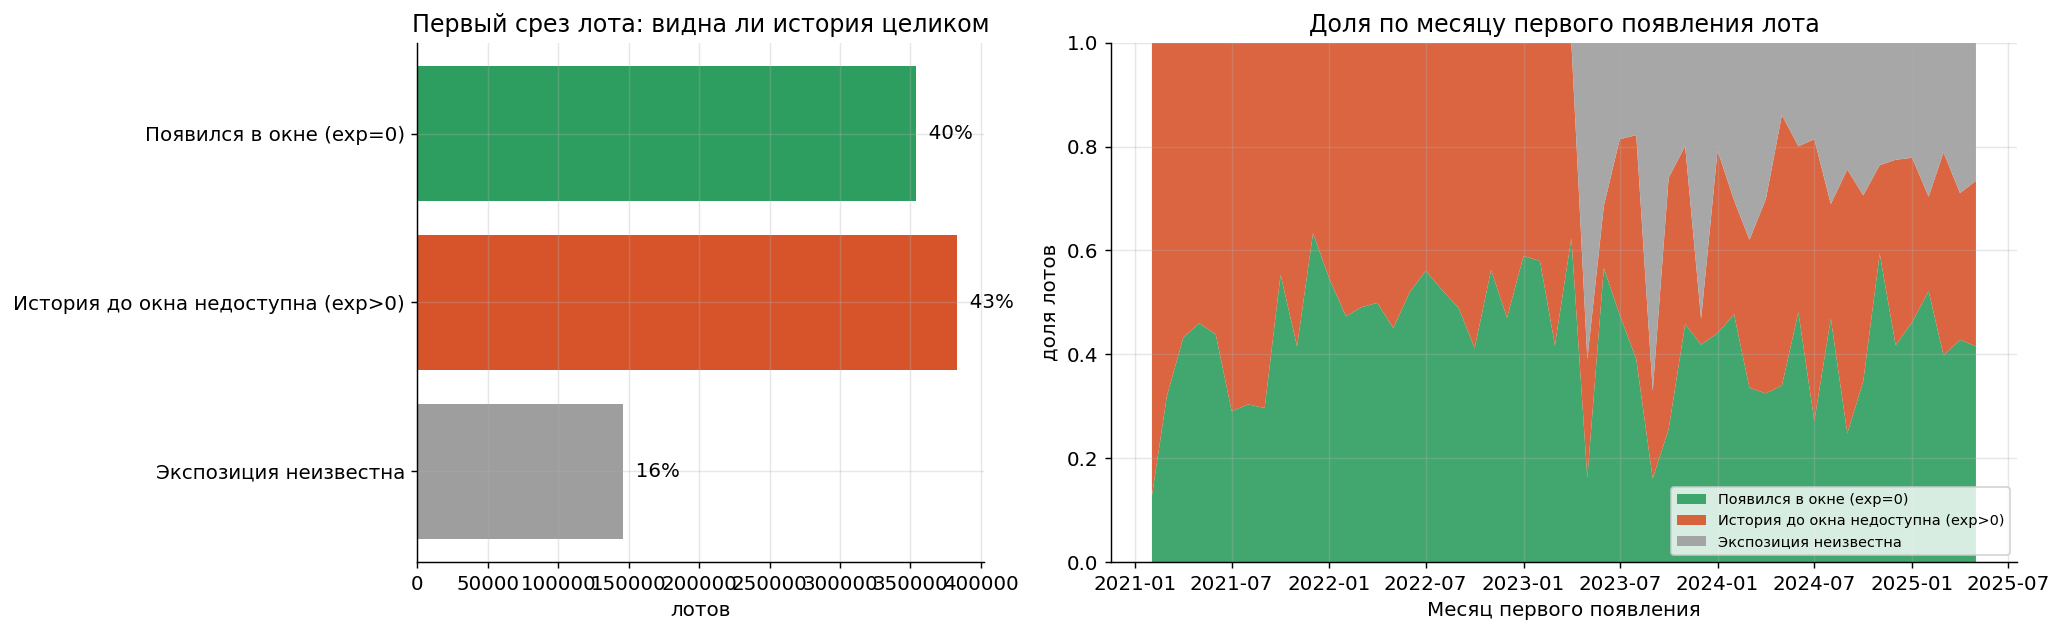

  Появился в окне (exp=0)                   354,049  (40.1%)
  История до окна недоступна (exp>0)        382,969  (43.4%)
  Экспозиция неизвестна                     145,629  (16.5%)


In [9]:
first = df[df["row_number"] == 1].copy()
exp = first["exposure"].astype("float64")
first["история"] = np.where(np.isnan(exp), "Экспозиция неизвестна",
                    np.where(exp == 0, "Появился в окне (exp=0)", "История до окна недоступна (exp>0)"))

order = ["Появился в окне (exp=0)", "История до окна недоступна (exp>0)", "Экспозиция неизвестна"]
colors = {"Появился в окне (exp=0)": C3, "История до окна недоступна (exp>0)": C2, "Экспозиция неизвестна": "#9e9e9e"}

fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1.6]})

# A: общий расклад по лотам
vc = first["история"].value_counts().reindex(order)
axA.barh(order[::-1], vc.values[::-1], color=[colors[o] for o in order[::-1]])
for y, c in enumerate(vc.values[::-1]):
    axA.text(c, y, f"  {100*c/len(first):.0f}%", va="center")
axA.set_title("Первый срез лота: видна ли история целиком")
axA.set_xlabel("лотов")

# B: доля по месяцу первого появления лота
first["m"] = first["file_date"].dt.to_period("M").dt.start_time
piv = (first.groupby(["m", "история"]).size().unstack(fill_value=0)
            .reindex(columns=order, fill_value=0))
piv_sh = piv.div(piv.sum(axis=1), axis=0)
axB.stackplot(piv_sh.index, [piv_sh[o].values for o in order],
              labels=order, colors=[colors[o] for o in order], alpha=0.9)
axB.set_title("Доля по месяцу первого появления лота")
axB.set_xlabel("Месяц первого появления")
axB.set_ylabel("доля лотов")
axB.set_ylim(0, 1)
axB.legend(loc="lower right", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "04_history_completeness.png", bbox_inches="tight")
plt.show()

for o in order:
    print(f"  {o:<40s} {vc[o]:>8,}  ({100*vc[o]/len(first):.1f}%)")


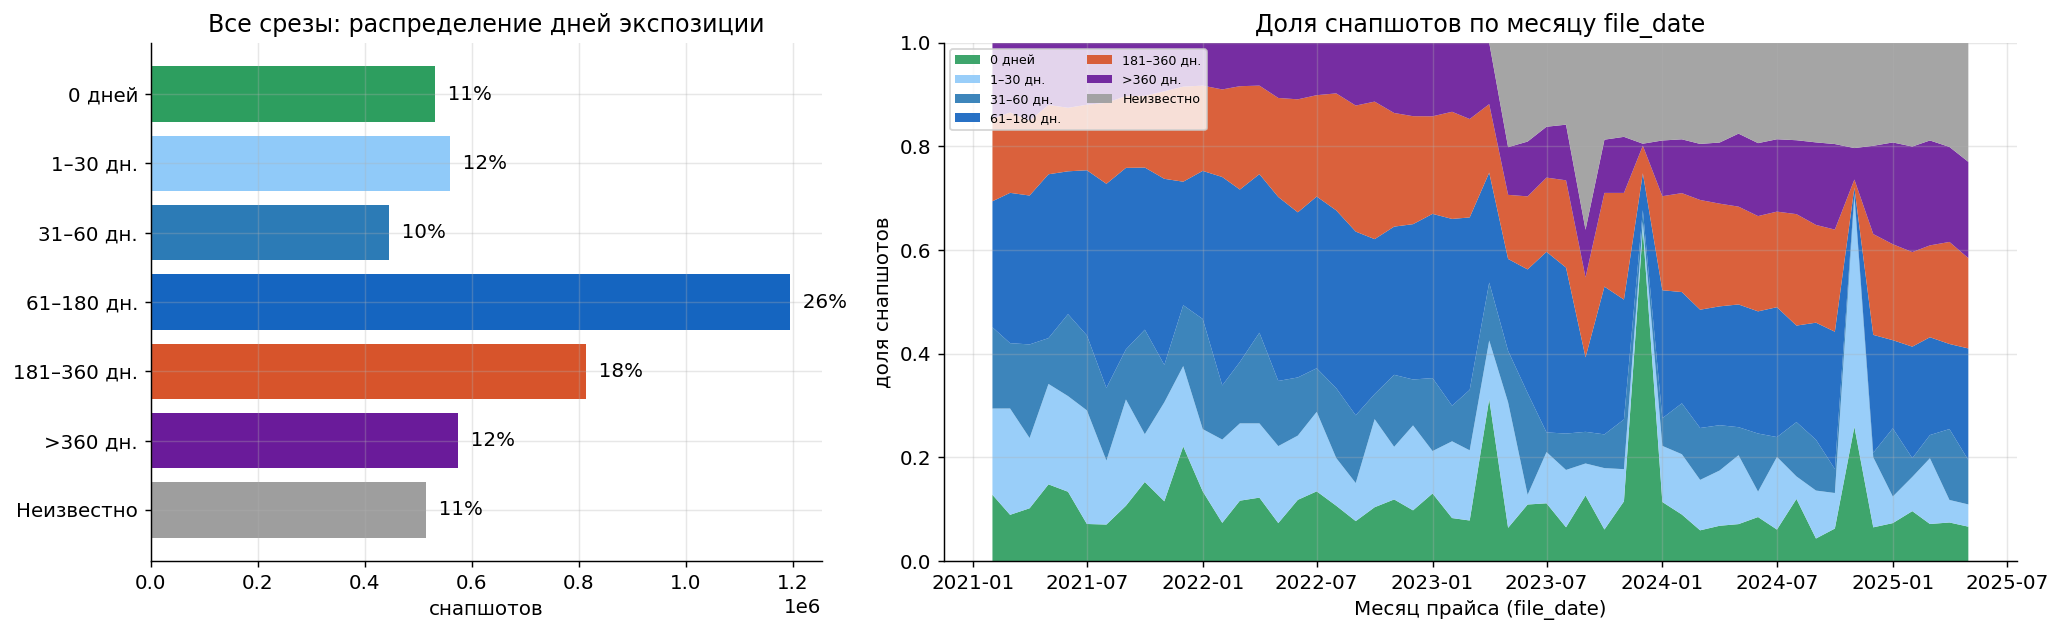

  0 дней            531,316  (11.5%)
  1–30 дн.          560,001  (12.1%)
  31–60 дн.         445,253  (9.6%)
  61–180 дн.      1,193,550  (25.8%)
  181–360 дн.       813,193  (17.6%)
  >360 дн.          574,278  (12.4%)
  Неизвестно        513,860  (11.1%)


In [10]:
EXPOSURE_ORDER = [
    "0 дней", "1–30 дн.", "31–60 дн.", "61–180 дн.", "181–360 дн.", ">360 дн.", "Неизвестно",
]
EXPOSURE_COLORS = {
    "0 дней": C3, "1–30 дн.": "#90caf9", "31–60 дн.": C1,
    "61–180 дн.": "#1565c0", "181–360 дн.": C2, ">360 дн.": "#6a1b9a", "Неизвестно": "#9e9e9e",
}

def _exposure_bucket(x: float) -> str:
    if pd.isna(x):
        return "Неизвестно"
    if x <= 0:
        return "0 дней"
    if x <= 30:
        return "1–30 дн."
    if x <= 60:
        return "31–60 дн."
    if x <= 180:
        return "61–180 дн."
    if x <= 360:
        return "181–360 дн."
    return ">360 дн."

exp = df["exposure"].astype("float64")
df["exposure_bucket"] = exp.map(_exposure_bucket)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1.6]})

vc = df["exposure_bucket"].value_counts().reindex(EXPOSURE_ORDER).fillna(0).astype(int)
axA.barh(EXPOSURE_ORDER[::-1], vc.values[::-1],
         color=[EXPOSURE_COLORS[o] for o in EXPOSURE_ORDER[::-1]])
for y, c in enumerate(vc.values[::-1]):
    axA.text(c, y, f"  {100*c/len(df):.0f}%", va="center")
axA.set_title("Все срезы: распределение дней экспозиции")
axA.set_xlabel("снапшотов")

monthly = df.assign(m=df["file_date"].dt.to_period("M").dt.start_time)
piv = (monthly.groupby(["m", "exposure_bucket"]).size()
              .unstack(fill_value=0)
              .reindex(columns=EXPOSURE_ORDER, fill_value=0))
piv_sh = piv.div(piv.sum(axis=1), axis=0)
axB.stackplot(piv_sh.index, [piv_sh[o].values for o in EXPOSURE_ORDER],
              labels=EXPOSURE_ORDER, colors=[EXPOSURE_COLORS[o] for o in EXPOSURE_ORDER], alpha=0.92)
axB.set_title("Доля снапшотов по месяцу file_date")
axB.set_xlabel("Месяц прайса (file_date)")
axB.set_ylabel("доля снапшотов")
axB.set_ylim(0, 1)
axB.legend(loc="upper left", fontsize=7, ncol=2)

fig.tight_layout()
fig.savefig(FIG_DIR / "05_exposure_dynamics.png", bbox_inches="tight")
plt.show()

for o in EXPOSURE_ORDER:
    print(f"  {o:<14s} {vc[o]:>10,}  ({100*vc[o]/len(df):.1f}%)")

## 5. Обрывы лотов без сделки

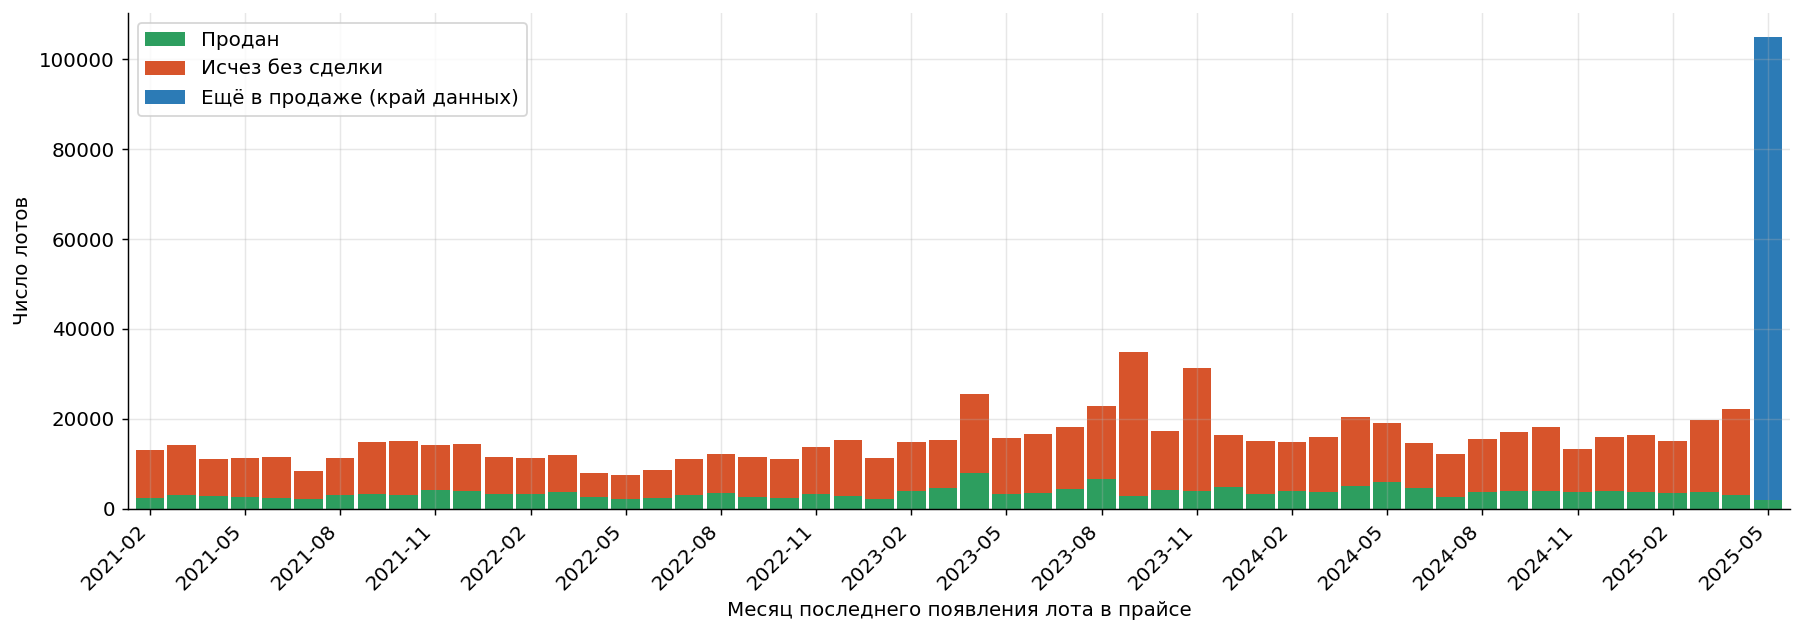

Исчезли без сделки: 67.5%  |  Продан: 20.8%  |  Ещё в продаже: 11.7%


In [11]:
# на каждый лот: последний месяц в прайсе, есть ли сделка, цензура (дожил до края данных)
edge = df["file_date"].max()
unit = df.groupby("unit_match_key").agg(
    last_fd=("file_date", "max"),
    has_deal=("registration_date_raw", lambda s: s.notna().any()),
)
unit["last_month"] = unit["last_fd"].dt.to_period("M").dt.start_time
unit["статус"] = np.where(unit["has_deal"], "Продан",
                  np.where(unit["last_fd"].eq(edge), "Ещё в продаже (край данных)", "Исчез без сделки"))

comp = unit.groupby(["last_month", "статус"]).size().unstack(fill_value=0)
order = ["Продан", "Исчез без сделки", "Ещё в продаже (край данных)"]
comp = comp[[c for c in order if c in comp.columns]]

comp.index = comp.index.strftime("%Y-%m")  # строковая ось -> bar как категориальный
fig, ax = plt.subplots(figsize=(14, 5))
comp.plot.bar(ax=ax, stacked=True, width=0.9,
              color={"Продан": C3, "Исчез без сделки": C2, "Ещё в продаже (край данных)": C1})
ax.set_xticks(range(0, len(comp), 3))
ax.set_xticklabels(comp.index[::3], rotation=45, ha="right")
ax.set_xlabel("Месяц последнего появления лота в прайсе")
ax.set_ylabel("Число лотов")
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_dropouts.png", bbox_inches="tight")
plt.show()

n = len(unit)
print(f"Исчезли без сделки: {(unit['статус']=='Исчез без сделки').mean()*100:.1f}%  |  "
      f"Продан: {(unit['статус']=='Продан').mean()*100:.1f}%  |  "
      f"Ещё в продаже: {(unit['статус']=='Ещё в продаже (край данных)').mean()*100:.1f}%")


## 6. Задержка: последний прайс → регистрация сделки

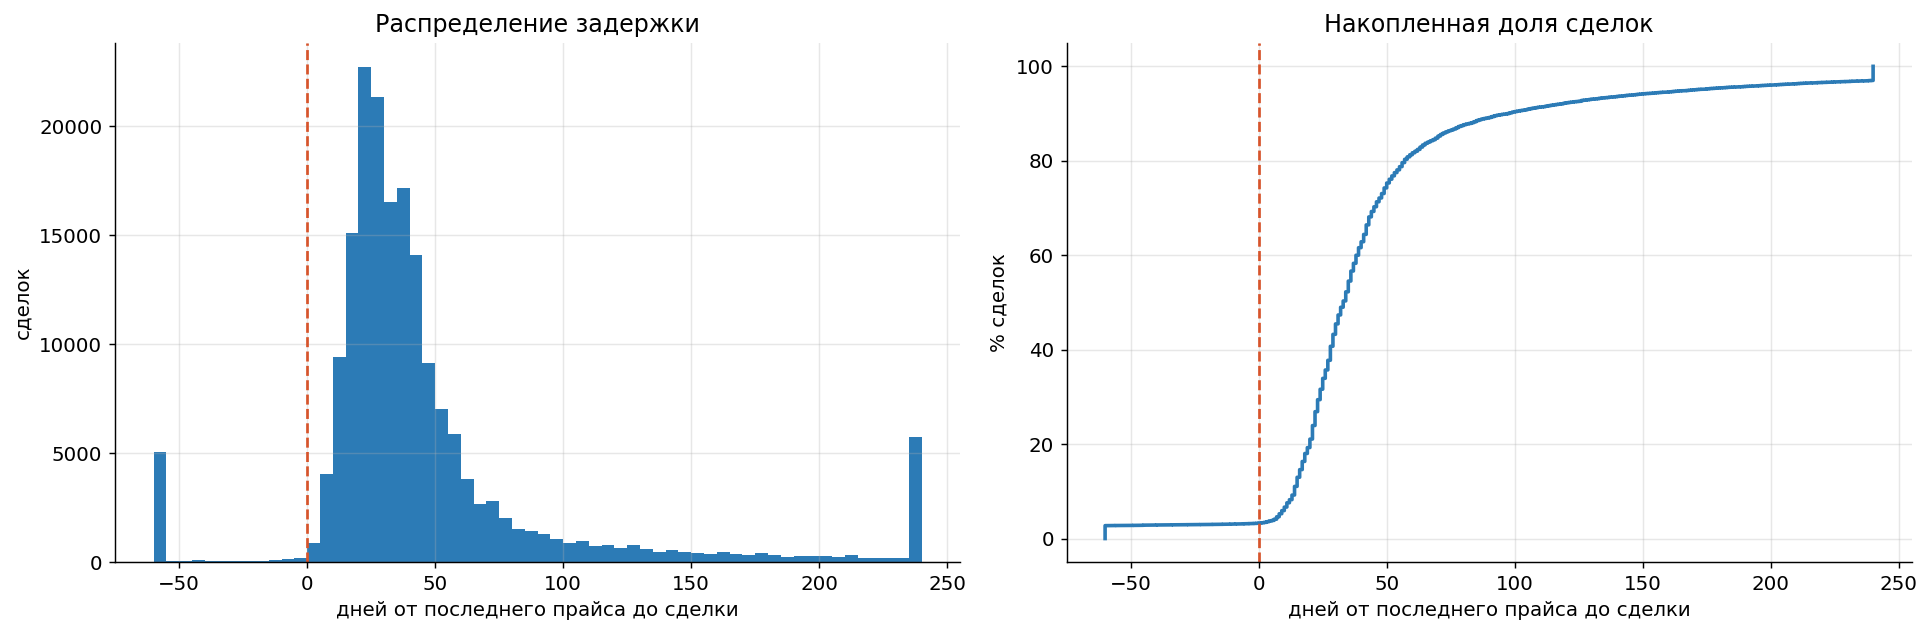

Сделок до последнего прайса (delta<0): 3.2%  |  медиана задержки: 33 дн.


In [12]:
# сколько дней проходит между последним появлением лота в прайсе и регистрацией сделки
delta = sold["delta"].clip(-60, 240)

fig, (axH, axC) = plt.subplots(1, 2, figsize=(15, 5))

axH.hist(delta, bins=60, color=C1, edgecolor="none")
axH.axvline(0, color=C2, ls="--", lw=1.5)
axH.set_title("Распределение задержки")
axH.set_xlabel("дней от последнего прайса до сделки")
axH.set_ylabel("сделок")

order = np.sort(sold["delta"].clip(-60, 240).values)
cdf = np.arange(1, len(order) + 1) / len(order)
axC.plot(order, 100 * cdf, color=C1, lw=2)
axC.axvline(0, color=C2, ls="--", lw=1.5)
axC.set_title("Накопленная доля сделок")
axC.set_xlabel("дней от последнего прайса до сделки")
axC.set_ylabel("% сделок")

fig.tight_layout()
fig.savefig(FIG_DIR / "07_delay.png", bbox_inches="tight")
plt.show()

print(f"Сделок до последнего прайса (delta<0): {(sold['delta']<0).mean()*100:.1f}%  |  "
      f"медиана задержки: {int(sold['delta'].median())} дн.")


## 7. Статус лота → колонка `unit_status`

Добавляем в датасет колонку со статусом лота:
- **продан** — есть сопоставленная сделка;
- **обрыв без сделки** — лот исчез из прайса до края данных, сделки нет;
- **цензурирован** — лот ещё в прайсе на последнюю дату данных, сделки пока нет.

In [13]:
edge = df["file_date"].max()
u = df.groupby("unit_match_key").agg(
    last_fd=("file_date", "max"),
    has_deal=("registration_date_raw", lambda s: s.notna().any()),
)
u["unit_status"] = np.where(u["has_deal"], "продан",
                    np.where(u["last_fd"].eq(edge), "цензурирован", "обрыв без сделки"))

df["unit_status"] = df["unit_match_key"].map(u["unit_status"]).astype("string")
df.to_parquet(EDA_LEFT_PARQUET, index=False)

print("Добавлена колонка unit_status. Распределение по лотам:")
display(u["unit_status"].value_counts().rename("лотов").to_frame().assign(
    доля=lambda x: (100 * x["лотов"] / len(u)).round(1)))
print(f"Сохранено: {EDA_LEFT_PARQUET.name}  ({df.shape[1]} колонок)")

Добавлена колонка unit_status. Распределение по лотам:


,лотов,доля
unit_status,,
обрыв без сделки,595872,67.5
продан,183578,20.8
цензурирован,103197,11.7


Сохранено: eda_left.parquet  (41 колонок)


## Конверсия по позиции цены в сегменте

Эмпирическая доля продаж за 30 дней по децилям относительной цены лота (`price` / медиана сегмента «район × класс × комнатность» на тот же срез — та же логика, что в признаке `rel_price` на этапе 04). Показывает асимметрию ценовой чувствительности ещё до построения модели.

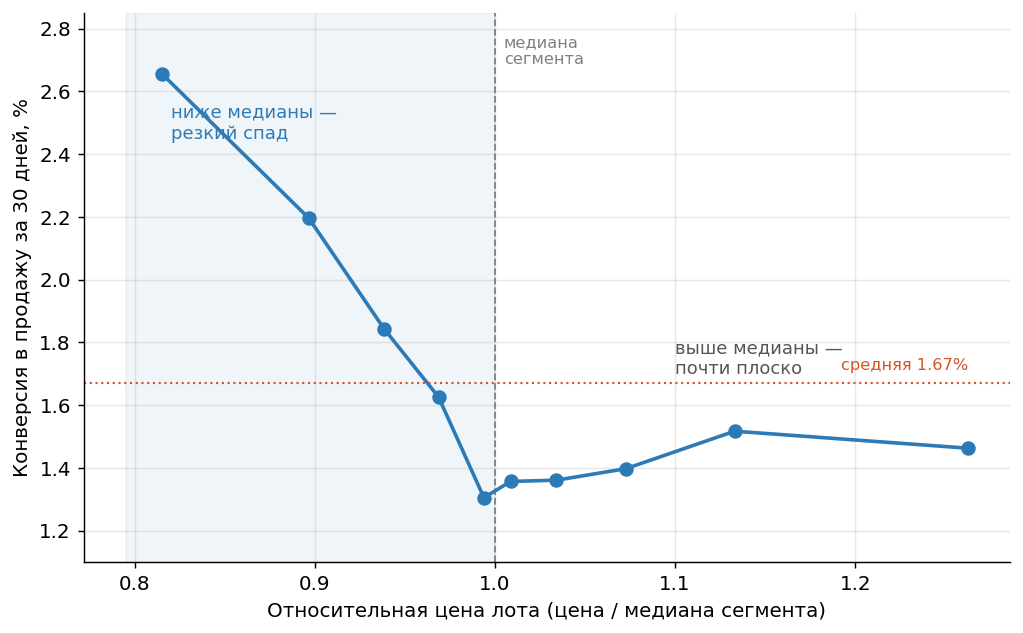

Конверсия по децилю относительной цены:
  дециль  1  rel=0.815  conv=2.66%
  дециль  2  rel=0.897  conv=2.20%
  дециль  3  rel=0.939  conv=1.84%
  дециль  4  rel=0.969  conv=1.63%
  дециль  5  rel=0.994  conv=1.31%
  дециль  6  rel=1.009  conv=1.36%
  дециль  7  rel=1.034  conv=1.36%
  дециль  8  rel=1.073  conv=1.40%
  дециль  9  rel=1.133  conv=1.52%
  дециль 10  rel=1.263  conv=1.46%
  средняя конверсия: 1.67%


In [14]:
# rel_price = price / медиана цены сегмента (район × класс × комнатность) на том же срезе
SEG = ["district", "project_class", "room_count"]
seg_med = df.groupby(SEG + ["file_date"])["price"].transform("median")
m = pd.DataFrame({"rel_price": df["price"] / seg_med, "y": df["is_sold_next_month"]})
m = m.dropna(subset=["rel_price"])
m = m[m["y"].notna()]
m["dec"] = pd.qcut(m["rel_price"], 10, labels=False, duplicates="drop")
g = m.groupby("dec").agg(conv=("y", "mean"), relp=("rel_price", "median")).reset_index()
overall = m["y"].mean()

x, y = g["relp"].values, 100 * g["conv"].values
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_ylim(1.1, 2.85)
ax.axvspan(x.min() - 0.02, 1.0, color=C1, alpha=0.07)
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.plot(x, y, "-o", color=C1, lw=2, ms=7)
ax.axhline(100 * overall, color=C2, ls=":", lw=1.2)
ax.text(x.max(), 100 * overall + 0.03, f"средняя {100*overall:.2f}%",
        va="bottom", ha="right", color=C2, fontsize=9)
ax.text(1.005, 2.78, "медиана\nсегмента", va="top", ha="left", color="gray", fontsize=9)
ax.annotate("ниже медианы —\nрезкий спад", xy=(0.90, 2.20), xytext=(0.82, 2.45),
            fontsize=10, color=C1)
ax.annotate("выше медианы —\nпочти плоско", xy=(1.10, 1.40), xytext=(1.10, 1.70),
            fontsize=10, color="#555")
ax.set_xlabel("Относительная цена лота (цена / медиана сегмента)")
ax.set_ylabel("Конверсия в продажу за 30 дней, %")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_conversion_by_relprice.png", bbox_inches="tight")
plt.show()

print("Конверсия по децилю относительной цены:")
for _, r in g.iterrows():
    print(f"  дециль {int(r['dec'])+1:2}  rel={r['relp']:.3f}  conv={100*r['conv']:.2f}%")
print(f"  средняя конверсия: {100*overall:.2f}%")
